<a href="https://colab.research.google.com/github/Monikka-R/Seasonal-Agriculture-Performance/blob/main/Seasonal_Agriculture_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [185]:
import pandas as pd

url = "https://raw.githubusercontent.com/Monikka-R/Seasonal-Agriculture-Performance/main/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [187]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [188]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby('Season')[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [189]:
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100

df[['Season', 'Revenue_INR', 'Profit_INR', 'Profit_Margin_pct']].head()

,Season,Revenue_INR,Profit_INR,Profit_Margin_pct
0,Kharif,30810,-11852,-38.468030
1,Kharif,40401,-451950,-1118.660429
2,Rabi,190466,-124744,-65.494104
3,Kharif,200740,-95704,-47.675600
4,Zaid,193607,-144352,-74.559288


In [190]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [191]:
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df['Yield_Tonnes_Ha'] < lower_limit) |
    (df['Yield_Tonnes_Ha'] > upper_limit)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)
print("Number of yield outliers:", len(outliers))

Q1: 1.05
Q3: 2.83
IQR: 1.78
Lower limit: -1.6199999999999999
Upper limit: 5.5
Number of yield outliers: 302


In [192]:
outliers[['Crop', 'Season', 'Yield_Tonnes_Ha']].sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
).head(20)

,Crop,Season,Yield_Tonnes_Ha
1715,Sugarcane,Kharif,101.44
3423,Sugarcane,Kharif,95.79
3525,Sugarcane,Rabi,93.13
1464,Sugarcane,Kharif,91.98
3523,Sugarcane,Kharif,91.46
2782,Sugarcane,Rabi,91.32
644,Sugarcane,Kharif,89.34
2847,Sugarcane,Kharif,87.76
357,Sugarcane,Rabi,84.75
1178,Sugarcane,Kharif,83.79


In [193]:
outliers['Crop'].value_counts()

,count
Crop,
Sugarcane,293
Maize,7
Rice,2


In [194]:
df['Season'].value_counts()


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


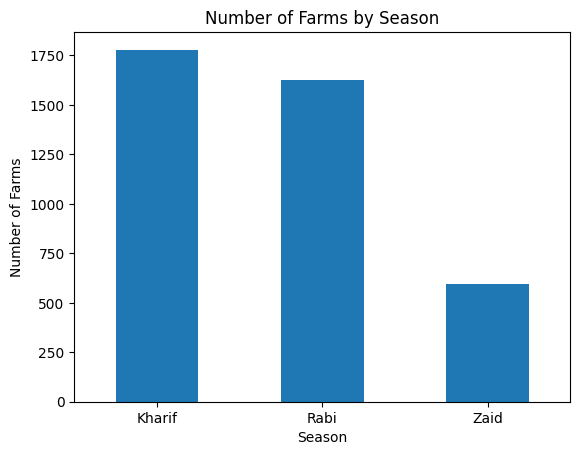

In [195]:
import matplotlib.pyplot as plt

season_counts = df['Season'].value_counts().reindex(
    ['Kharif', 'Rabi', 'Zaid']
)

season_counts.plot(kind='bar')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.show()

In [196]:
crop_counts = df['Crop'].value_counts()

print(crop_counts)

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


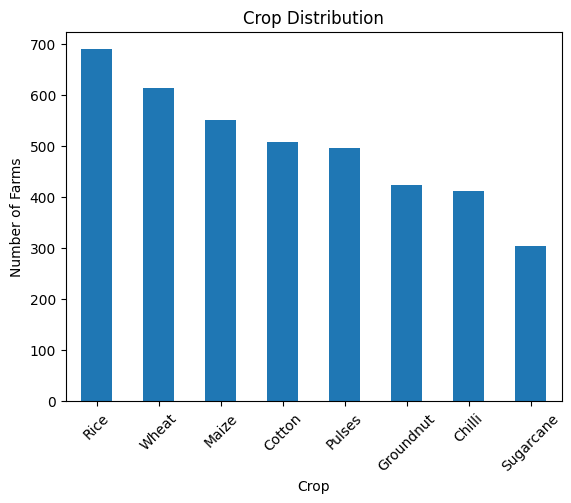

In [197]:
crop_counts = df['Crop'].value_counts()

crop_counts.plot(kind='bar')

plt.title('Crop Distribution')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)
plt.show()

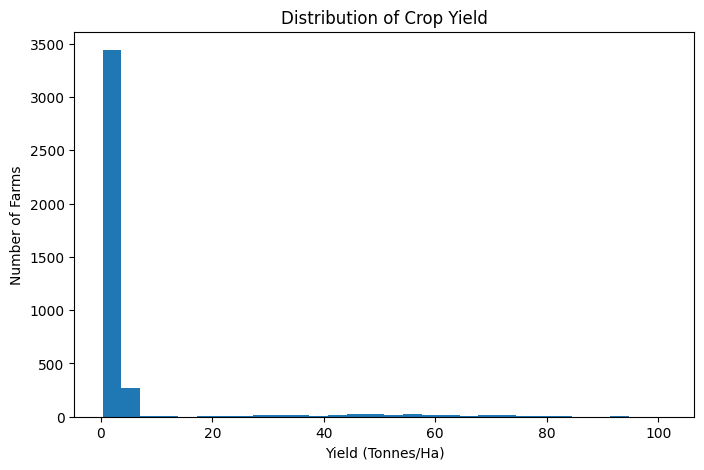

In [198]:
plt.figure(figsize=(8, 5))

plt.hist(df['Yield_Tonnes_Ha'], bins=30)

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')

plt.show()

In [199]:
avg_yield_crop = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(avg_yield_crop)

Crop
Sugarcane    46.641836
Maize         2.709074
Rice          2.431638
Wheat         2.108225
Chilli        1.541481
Groundnut     1.322642
Cotton        1.229311
Pulses        0.920766
Name: Yield_Tonnes_Ha, dtype: float64


In [200]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print(season_yield)

Season
Kharif    5.629438
Rabi      5.038451
Zaid      4.638872
Name: Yield_Tonnes_Ha, dtype: float64


In [201]:
season_profit = df.groupby('Season')['Profit_INR'].mean().sort_values(ascending=False)

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


In [202]:
season_economics = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR',
    'Profit_INR'
]].mean()

print(season_economics)

          Revenue_INR  Total_Cost_INR     Profit_INR
Season                                              
Kharif  710719.055649   531804.408094  178914.647555
Rabi    601526.048556   513836.578365   87689.470191
Zaid    519171.904040   543976.728956  -24804.824916


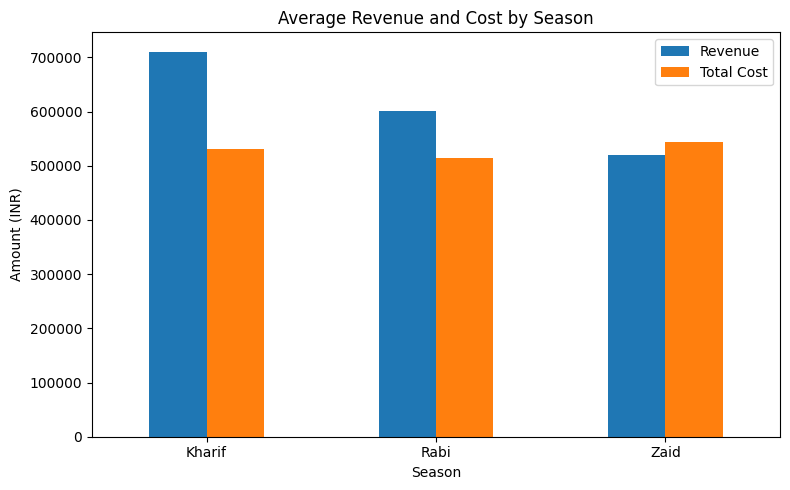

In [203]:
import matplotlib.pyplot as plt

season_economics = df.groupby('Season')[[
    'Revenue_INR',
    'Total_Cost_INR'
]].mean()

season_economics.plot(kind='bar', figsize=(8, 5))

plt.title('Average Revenue and Cost by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(['Revenue', 'Total Cost'])
plt.tight_layout()
plt.show()

In [204]:
irrigation_efficiency = df.groupby('Irrigation_Method')[
    'Water_Efficiency_t_per_1000m3'
].mean().sort_values(ascending=False)

print(irrigation_efficiency)

Irrigation_Method
Rainfed      7.563784
Drip         6.267129
Sprinkler    4.669805
Flood        3.438853
Name: Water_Efficiency_t_per_1000m3, dtype: float64


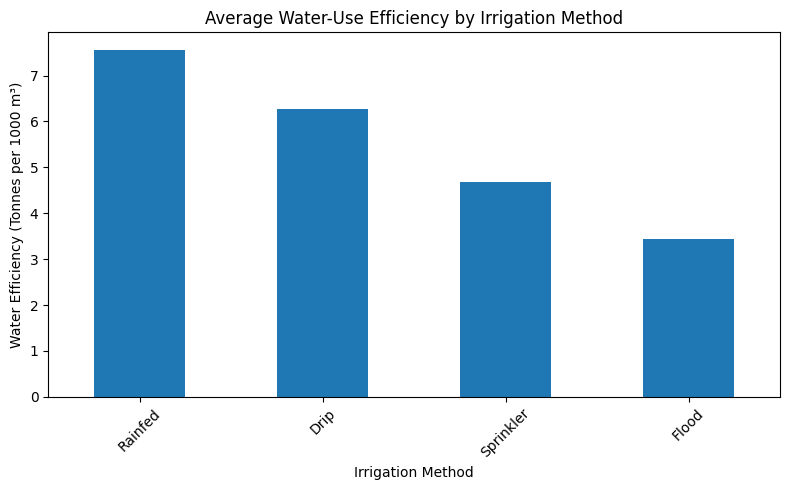

In [205]:
irrigation_efficiency.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Water-Use Efficiency by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [206]:
risk_by_season = df.groupby('Season')['Disease_Pest_Risk_pct'].mean()

print(risk_by_season)

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


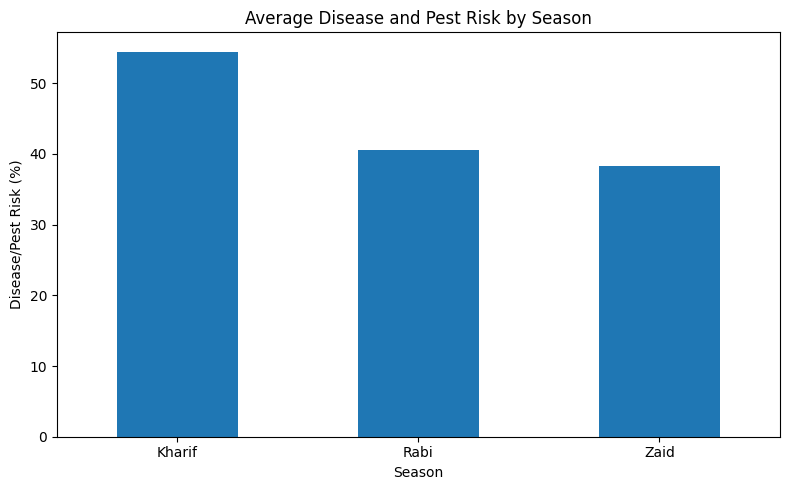

In [207]:
risk_by_season.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

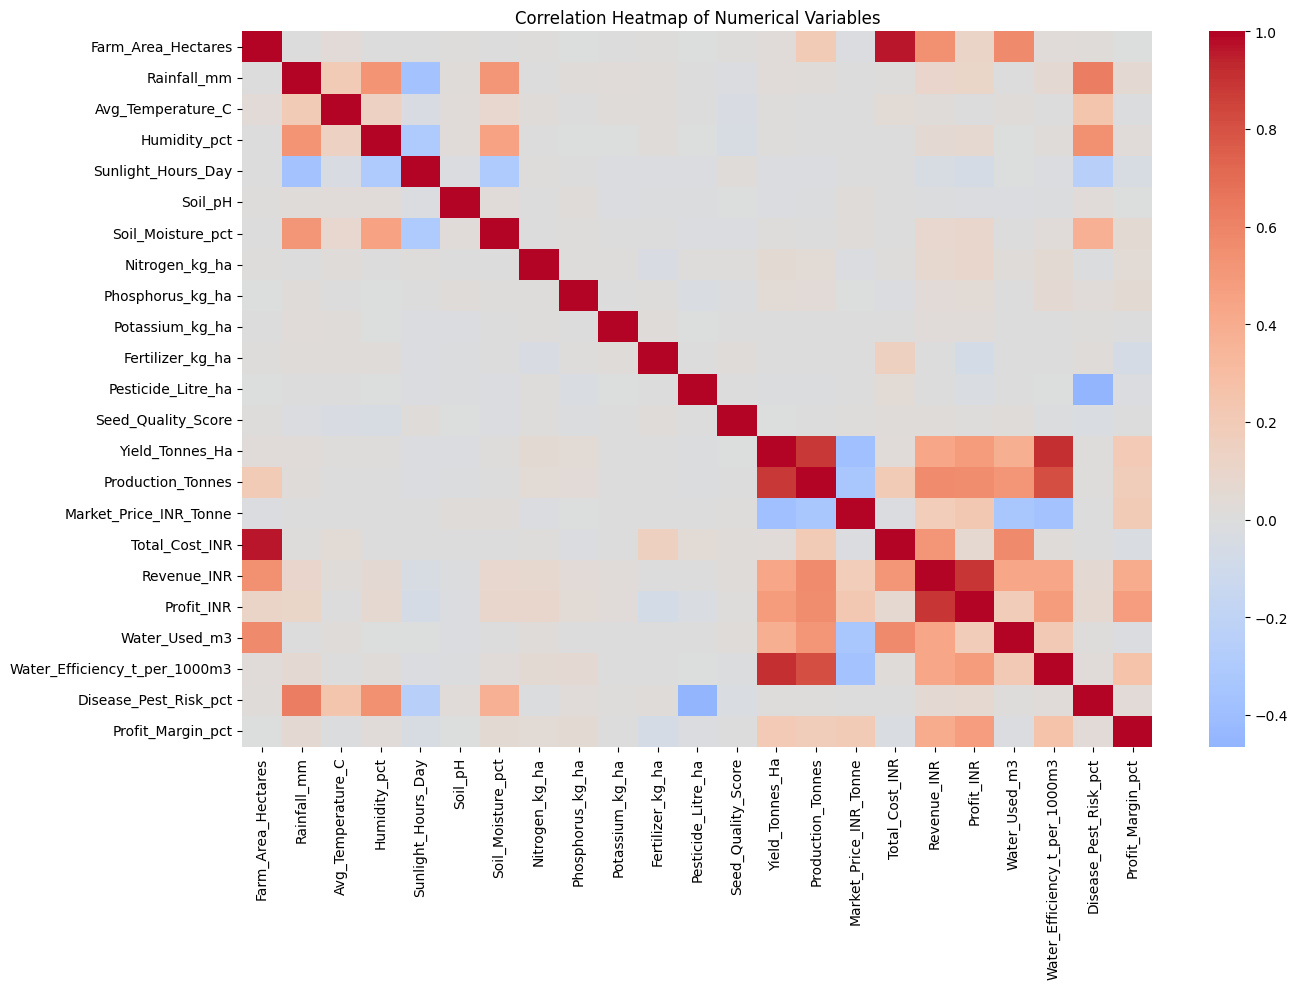

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

correlation = df.select_dtypes(include='number').corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

In [209]:
yield_correlation = df.select_dtypes(include='number').corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)

print(yield_correlation)

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912561
Production_Tonnes                0.882804
Profit_INR                       0.488459
Revenue_INR                      0.432139
Water_Used_m3                    0.386298
Profit_Margin_pct                0.205021
Nitrogen_kg_ha                   0.053167
Phosphorus_kg_ha                 0.047974
Total_Cost_INR                   0.030606
Farm_Area_Hectares               0.030194
Rainfall_mm                      0.028836
Disease_Pest_Risk_pct            0.014351
Humidity_pct                     0.012337
Soil_Moisture_pct                0.011101
Avg_Temperature_C                0.010026
Potassium_kg_ha                  0.003363
Fertilizer_kg_ha                -0.000003
Seed_Quality_Score              -0.007231
Pesticide_Litre_ha              -0.007789
Sunlight_Hours_Day              -0.015362
Soil_pH                         -0.020691
Market_Price_INR_Tonne          -0.382627
Name: Yield_Tonnes_Ha, dtype: floa

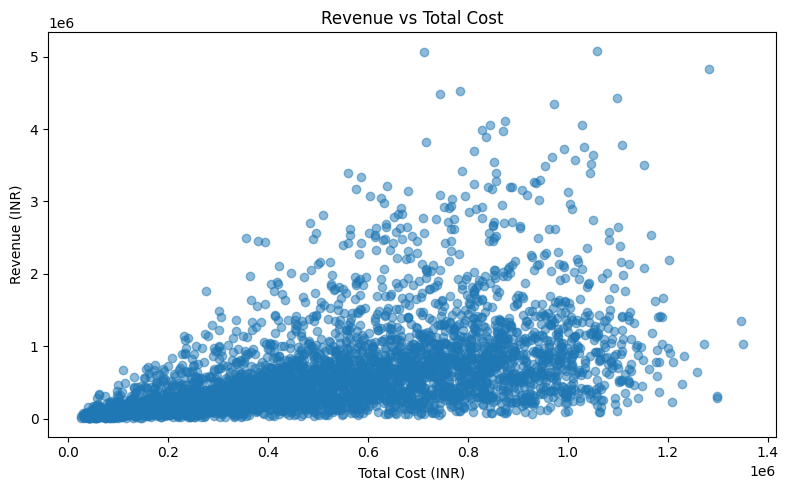

In [210]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Total_Cost_INR'],
    df['Revenue_INR'],
    alpha=0.5
)

plt.title('Revenue vs Total Cost')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')

plt.tight_layout()
plt.show()

In [211]:
yield_by_irrigation = df.groupby('Irrigation_Method')[
    'Yield_Tonnes_Ha'
].mean().sort_values(ascending=False)

print(yield_by_irrigation)

Irrigation_Method
Drip         6.577290
Sprinkler    5.160082
Flood        4.863366
Rainfed      4.602392
Name: Yield_Tonnes_Ha, dtype: float64


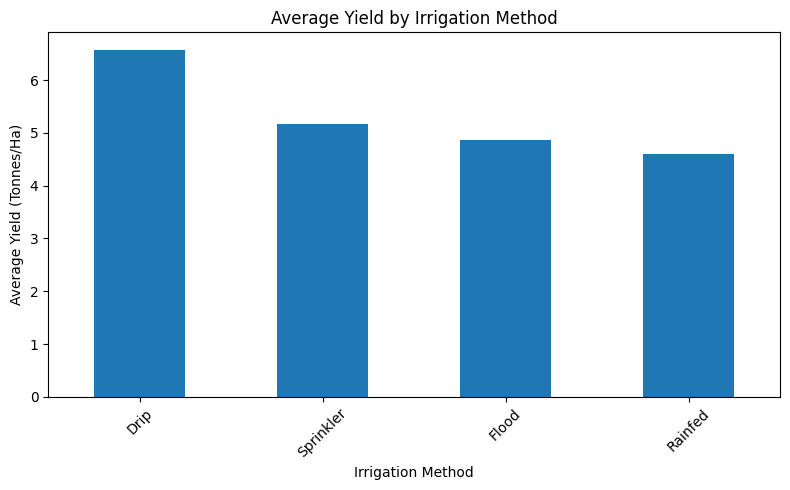

In [212]:
yield_by_irrigation.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [213]:
yield_by_state = df.groupby('State')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print(yield_by_state)

State
Punjab            6.121116
Karnataka         5.686278
Gujarat           5.657766
Telangana         5.043857
Maharashtra       5.017324
Madhya Pradesh    4.989135
Tamil Nadu        4.874515
Andhra Pradesh    4.628318
Name: Yield_Tonnes_Ha, dtype: float64


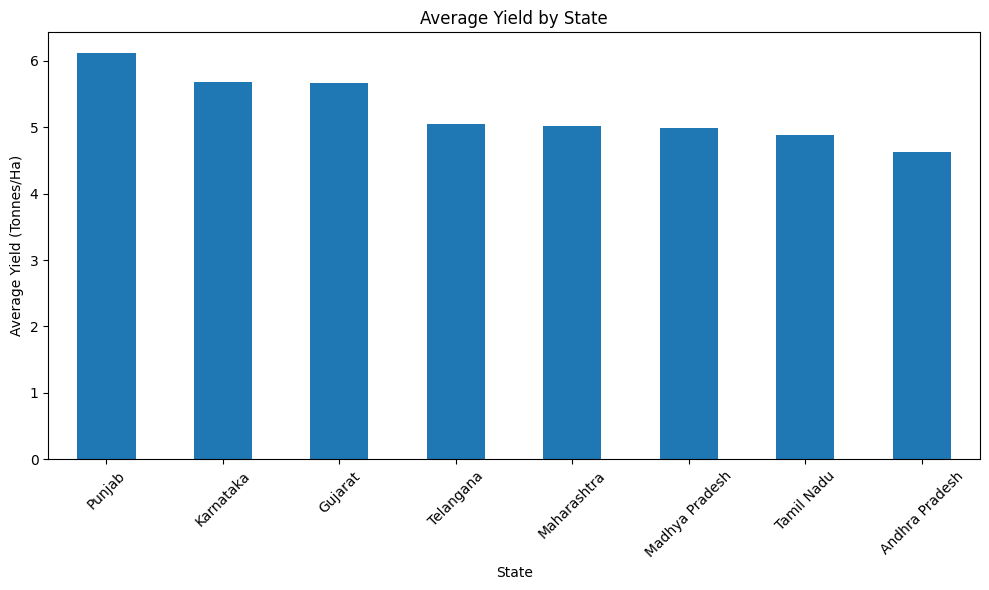

In [214]:
yield_by_state.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [215]:
profit_by_crop = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

print(profit_by_crop)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


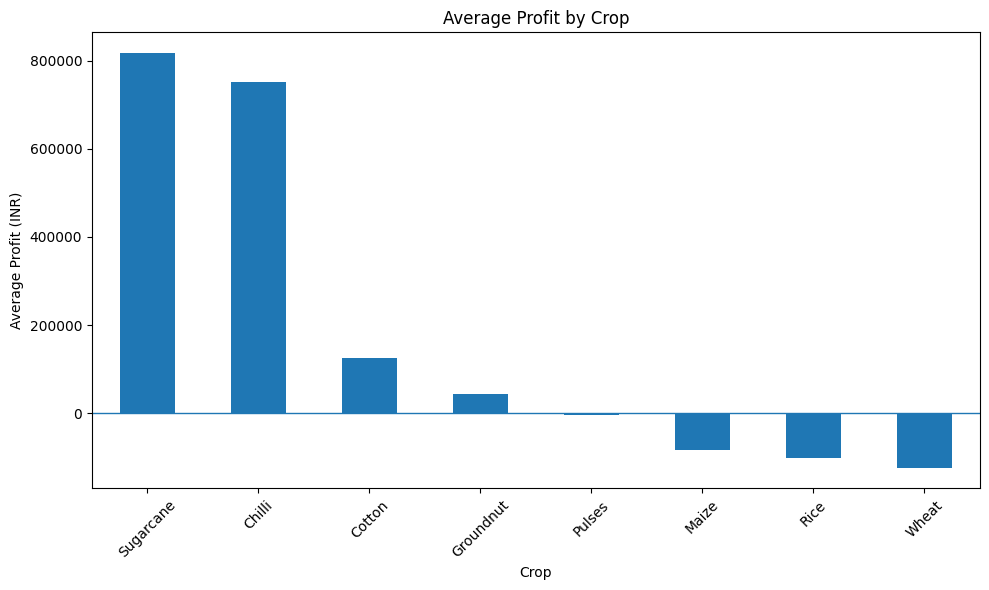

In [216]:
profit_by_crop.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

In [217]:
profit_margin_season = df.groupby('Season')['Profit_Margin_pct'].mean()

print(profit_margin_season)

Season
Kharif   -38.644541
Rabi     -44.267645
Zaid     -69.354573
Name: Profit_Margin_pct, dtype: float64


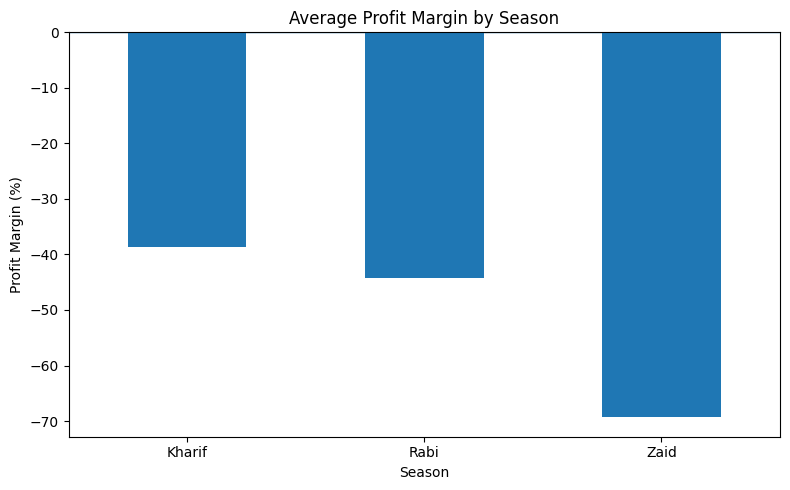

In [218]:
profit_margin_season.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Profit Margin by Season')
plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)
plt.axhline(0, linewidth=1)
plt.tight_layout()
plt.show()

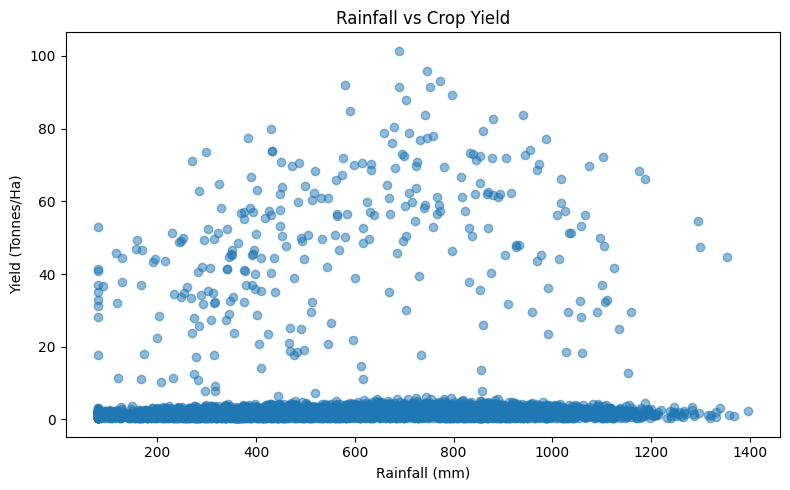

In [219]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Rainfall_mm'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

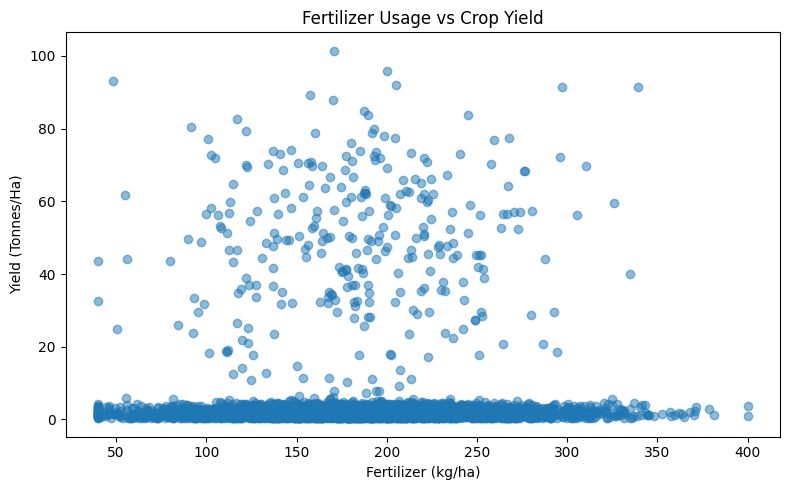

In [220]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Fertilizer_kg_ha'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

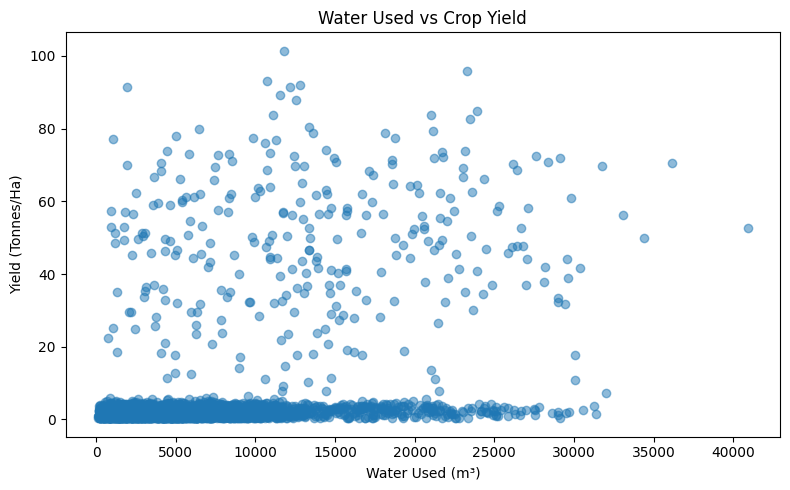

In [221]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Used_m3'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Water Used vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

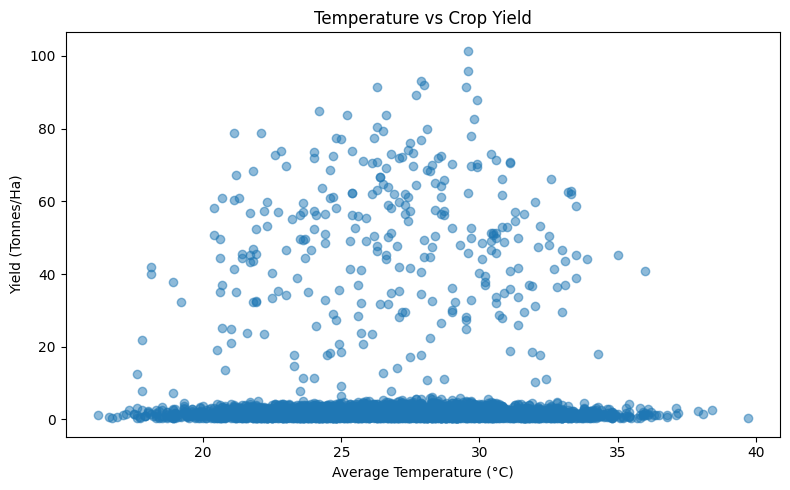

In [222]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Avg_Temperature_C'],
    df['Yield_Tonnes_Ha'],
    alpha=0.5
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [223]:
top_crop_season = (
    df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha']
      .mean()
      .reset_index()
)

top_crop_season = top_crop_season.loc[
    top_crop_season.groupby('Season')['Yield_Tonnes_Ha'].idxmax()
]

print(top_crop_season)

    Season       Crop  Yield_Tonnes_Ha
6   Kharif  Sugarcane        53.459120
14    Rabi  Sugarcane        43.284884
22    Zaid  Sugarcane        38.423922


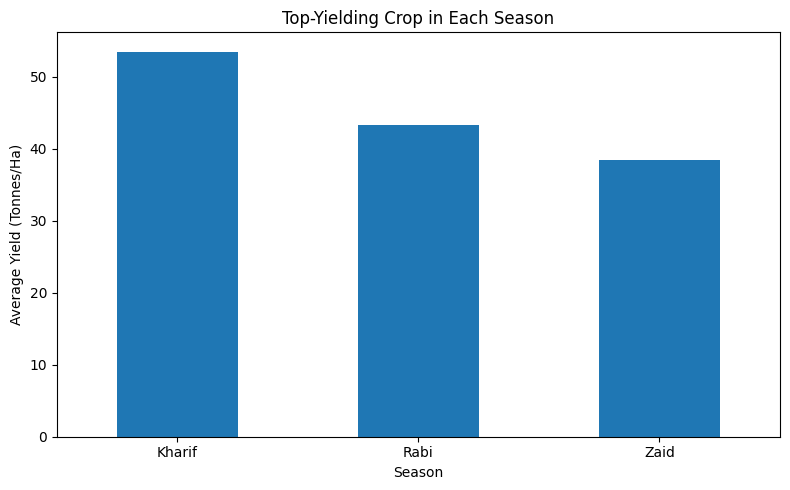

In [224]:
top_crop_season.plot(
    x='Season',
    y='Yield_Tonnes_Ha',
    kind='bar',
    figsize=(8, 5),
    legend=False
)

plt.title('Top-Yielding Crop in Each Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [225]:
df['Moisture_Level'] = pd.cut(
    df['Soil_Moisture_pct'],
    bins=[0, 15, 25, 35, 50],
    labels=['Low', 'Medium', 'High', 'Very High']
)

moisture_yield = df.groupby(
    'Moisture_Level',
    observed=True
)['Yield_Tonnes_Ha'].mean()

print(moisture_yield)

Moisture_Level
Low          5.766706
Medium       5.142775
High         5.064987
Very High    6.169624
Name: Yield_Tonnes_Ha, dtype: float64


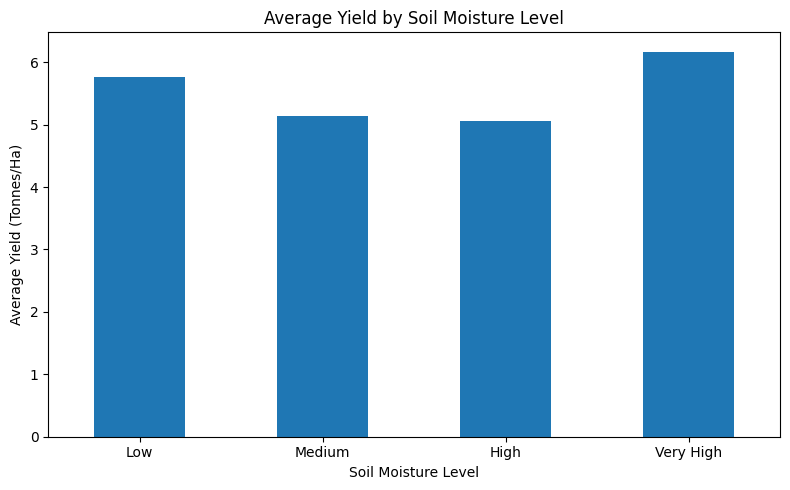

In [226]:
moisture_yield.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Yield by Soil Moisture Level')
plt.xlabel('Soil Moisture Level')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [227]:
best_crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

print("Most profitable crop:")
print(best_crop_profit.head(1))

print("\nLeast profitable crop:")
print(best_crop_profit.tail(1))

Most profitable crop:
Crop
Sugarcane    817187.986885
Name: Profit_INR, dtype: float64

Least profitable crop:
Crop
Wheat   -123398.337134
Name: Profit_INR, dtype: float64


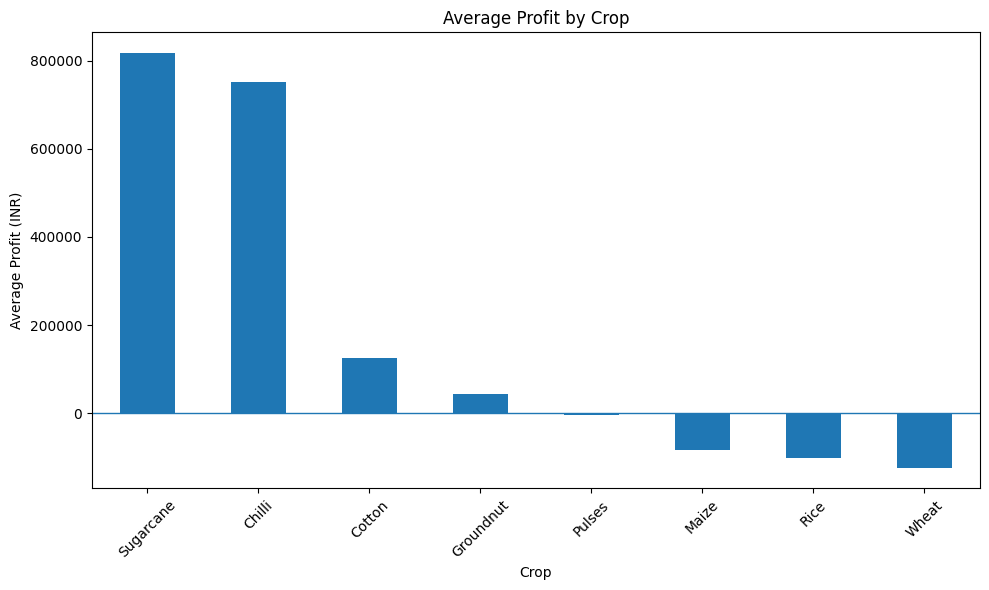

In [228]:
best_crop_profit.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, linewidth=1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [229]:
water_efficiency_season = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean().sort_values(ascending=False)

print(water_efficiency_season)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


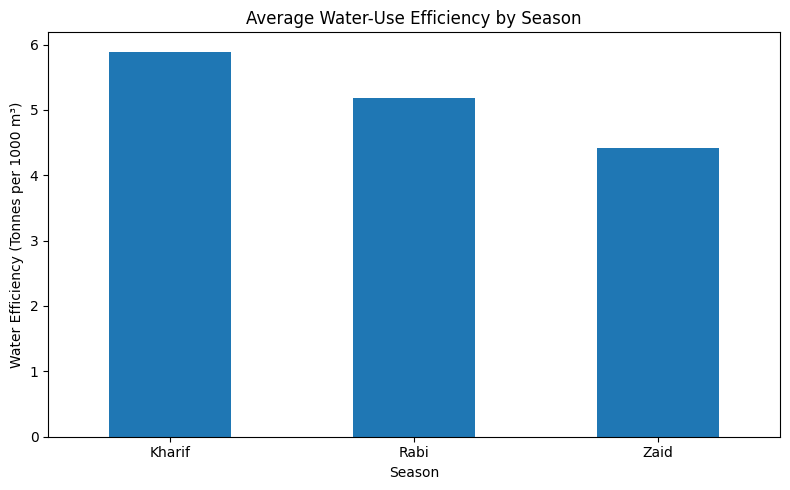

In [230]:
water_efficiency_season.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Water-Use Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes per 1000 m³)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [231]:
df['Risk_Level'] = pd.cut(
    df['Disease_Pest_Risk_pct'],
    bins=[0, 30, 60, 100],
    labels=['Low', 'Medium', 'High']
)

risk_yield = df.groupby(
    'Risk_Level',
    observed=True
)['Yield_Tonnes_Ha'].mean()

print(risk_yield)

Risk_Level
Low       5.032028
Medium    5.292653
High      5.098414
Name: Yield_Tonnes_Ha, dtype: float64


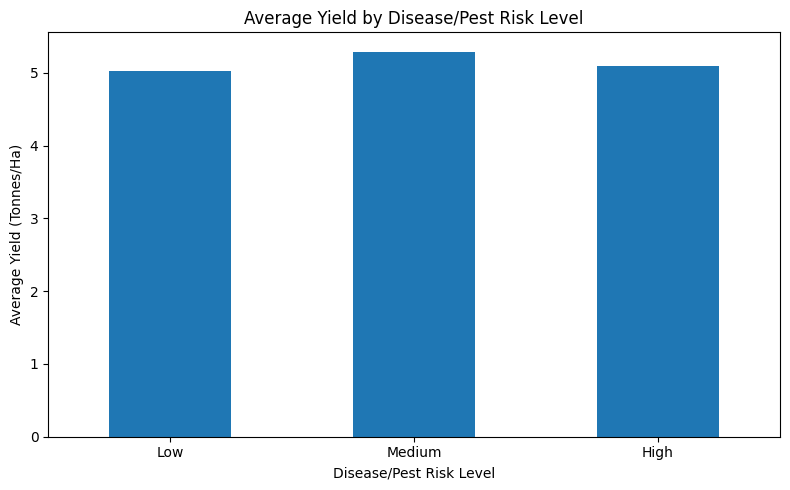

In [232]:
risk_yield.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Yield by Disease/Pest Risk Level')
plt.xlabel('Disease/Pest Risk Level')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [233]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4000, 31)

Missing values:
0

Duplicate rows:
0

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct', 'Profit_Margin_pct', 'Moisture_Level', 'Risk_Level']


In [234]:
print("===== KEY PROJECT INSIGHTS =====\n")

# 1. Largest season
season_count = df['Season'].value_counts()
print("1. Most represented season:")
print(season_count.idxmax(), "-", season_count.max(), "farms")

# 2. Highest average yield crop
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean()
print("\n2. Highest average-yielding crop:")
print(crop_yield.idxmax(), "-", round(crop_yield.max(), 2), "tonnes/ha")

# 3. Highest-yielding season
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()
print("\n3. Highest average-yielding season:")
print(season_yield.idxmax(), "-", round(season_yield.max(), 2), "tonnes/ha")

# 4. Most profitable season
season_profit = df.groupby('Season')['Profit_INR'].mean()
print("\n4. Most profitable season:")
print(season_profit.idxmax(), "-", round(season_profit.max(), 2), "INR")

# 5. Lowest-profit season
print("\n5. Lowest-profit season:")
print(season_profit.idxmin(), "-", round(season_profit.min(), 2), "INR")

# 6. Highest-profit crop
crop_profit = df.groupby('Crop')['Profit_INR'].mean()
print("\n6. Most profitable crop:")
print(crop_profit.idxmax(), "-", round(crop_profit.max(), 2), "INR")

# 7. Best water-efficiency season
season_water = df.groupby(
    'Season'
)['Water_Efficiency_t_per_1000m3'].mean()

print("\n7. Most water-efficient season:")
print(season_water.idxmax(), "-", round(season_water.max(), 2))

# 8. Number of yield outliers
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)
IQR = Q3 - Q1

outlier_count = (
    (df['Yield_Tonnes_Ha'] < Q1 - 1.5 * IQR) |
    (df['Yield_Tonnes_Ha'] > Q3 + 1.5 * IQR)
).sum()

print("\n8. Yield outliers identified:")
print(outlier_count)

===== KEY PROJECT INSIGHTS =====

1. Most represented season:
Kharif - 1779 farms

2. Highest average-yielding crop:
Sugarcane - 46.64 tonnes/ha

3. Highest average-yielding season:
Kharif - 5.63 tonnes/ha

4. Most profitable season:
Kharif - 178914.65 INR

5. Lowest-profit season:
Zaid - -24804.82 INR

6. Most profitable crop:
Sugarcane - 817187.99 INR

7. Most water-efficient season:
Kharif - 5.89

8. Yield outliers identified:
302


In [235]:
print("===== RECOMMENDATIONS =====\n")

print("1. Focus on improving productivity during the Zaid season.")
print("2. Improve cost management in Zaid because its average cost exceeds average revenue.")
print("3. Promote efficient irrigation methods to improve water-use efficiency.")
print("4. Use crop- and season-specific farming strategies rather than applying the same strategy everywhere.")
print("5. Monitor disease and pest risk regularly to support better crop management.")
print("6. Optimize fertilizer and water usage based on crop requirements.")
print("7. Use market-price and production-cost information when selecting crops.")
print("8. Investigate Sugarcane separately because its yield and profit values are much higher than most other crops.")

===== RECOMMENDATIONS =====

1. Focus on improving productivity during the Zaid season.
2. Improve cost management in Zaid because its average cost exceeds average revenue.
3. Promote efficient irrigation methods to improve water-use efficiency.
4. Use crop- and season-specific farming strategies rather than applying the same strategy everywhere.
5. Monitor disease and pest risk regularly to support better crop management.
6. Optimize fertilizer and water usage based on crop requirements.
7. Use market-price and production-cost information when selecting crops.
8. Investigate Sugarcane separately because its yield and profit values are much higher than most other crops.


In [236]:
print("===== PROJECT LIMITATIONS =====\n")

print("1. The analysis is based only on the available dataset.")
print("2. Correlation does not prove cause-and-effect relationships.")
print("3. Sugarcane has a very different yield scale compared with most crops.")
print("4. The number of farms is not equal across all seasons and crops.")
print("5. Some environmental and economic factors may not be fully represented.")
print("6. The analysis does not include long-term year-by-year trends.")

===== PROJECT LIMITATIONS =====

1. The analysis is based only on the available dataset.
2. Correlation does not prove cause-and-effect relationships.
3. Sugarcane has a very different yield scale compared with most crops.
4. The number of farms is not equal across all seasons and crops.
5. Some environmental and economic factors may not be fully represented.
6. The analysis does not include long-term year-by-year trends.


In [237]:
print("===== CONCLUSION =====\n")

print(
    "The Seasonal Agriculture Performance Analysis shows that "
    "agricultural performance varies across crops and seasons. "
    "Kharif recorded the highest average yield, profit, and water-use efficiency "
    "among the three seasons. Sugarcane showed exceptionally high average yield "
    "and profit compared with the other crops. In contrast, Zaid recorded a "
    "negative average profit because its average production cost was higher "
    "than its average revenue. The analysis also highlighted the importance "
    "of irrigation, environmental conditions, crop selection, and cost "
    "management in agricultural performance. Overall, data analytics can "
    "help identify performance patterns and support better-informed "
    "agricultural decision-making."
)

===== CONCLUSION =====

The Seasonal Agriculture Performance Analysis shows that agricultural performance varies across crops and seasons. Kharif recorded the highest average yield, profit, and water-use efficiency among the three seasons. Sugarcane showed exceptionally high average yield and profit compared with the other crops. In contrast, Zaid recorded a negative average profit because its average production cost was higher than its average revenue. The analysis also highlighted the importance of irrigation, environmental conditions, crop selection, and cost management in agricultural performance. Overall, data analytics can help identify performance patterns and support better-informed agricultural decision-making.
